# Clustering Clustering Algorithms

## part1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score

from sklearn.base import BaseEstimator, ClusterMixin

import skfuzzy as fuzz
from sklearn.decomposition import PCA

import math

from sklearn.cluster import KMeans, BisectingKMeans, SpectralClustering
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics.pairwise import euclidean_distances


from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.cluster import DBSCAN, OPTICS

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split

from sklearn.tree import plot_tree

from sklearn.model_selection import GridSearchCV, cross_val_score


In [2]:
df = pd.read_csv('football_clear.csv')

In [3]:
df.shape

(4700, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4700 entries, 0 to 4699
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          4700 non-null   object 
 1   Position      4700 non-null   object 
 2   Age           4700 non-null   int64  
 3   Team_from     4700 non-null   object 
 4   League_from   4700 non-null   object 
 5   Team_to       4700 non-null   object 
 6   League_to     4700 non-null   object 
 7   Season        4700 non-null   object 
 8   Market_value  3440 non-null   float64
 9   Transfer_fee  4700 non-null   int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 367.3+ KB


In [5]:
df_clean = df.copy()

## data cleaning

In [ ]:
# --- STEP A: Text Cleaning (Name, Season, Teams) ---
# Filter out invalid names (containing numbers or symbols)
invalid_name_pattern = r'[\d@#\$%\^&\*]'
df_clean = df_clean[~df_clean['Name'].str.contains(invalid_name_pattern, regex=True, na=False)]

# Keep only valid Season format (YYYY-YYYY)
df_clean = df_clean[df_clean['Season'].astype(str).str.match(r'^\d{4}-\d{4}$', na=False)]

# Filter out garbage text in Leagues/Teams (length < 3)
cols_to_check = ['League_from', 'League_to', 'Team_from', 'Team_to']
for col in cols_to_check:
    df_clean = df_clean[df_clean[col].astype(str).str.len() > 3]



# --- STEP B: Numeric Cleaning (Age) ---
# Coerce to numeric -> Drop NaNs -> Filter 15-45 range
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
df_clean = df_clean.dropna(subset=['Age'])
df_clean = df_clean[(df_clean['Age'] >= 15) & (df_clean['Age'] <= 45)]
df_clean['Age'] = df_clean['Age'].astype(int)



# --- STEP C: Categorical Cleaning (Position) ---
# Dictionary to fix typos (from Phase 1)
typo_corrections = {
    'heft Winger': 'Left Winger', 'LeftyWinger': 'Left Winger', 'Left Midfielg': 'Left Midfield',
    'Centrf-Forward': 'Centre-Forward', 'Centre-Forwaqd': 'Centre-Forward', 'CentrexForward': 'Centre-Forward',
    'RighthMidfield': 'Right Midfield', 'Right Wonger': 'Right Winger',
    'Goalkeeeer': 'Goalkeeper', 'Goalkeeped': 'Goalkeeper', 'Goalqeeper': 'Goalkeeper',
    'Defensive Midfiuld': 'Defensive Midfield', 'Defensive Mixfield': 'Defensive Midfield',
    'Centrb-Back': 'Centre-Back', 'Centre-gack': 'Centre-Back'
}
df_clean['Position'] = df_clean['Position'].replace(typo_corrections)

# Keep only valid positions
valid_positions = [
    'Goalkeeper', 'Centre-Back', 'Left-Back', 'Right-Back', 
    'Defensive Midfield', 'Central Midfield', 'Attacking Midfield', 
    'Left Winger', 'Right Winger', 'Centre-Forward', 'Second Striker',
    'Midfielder', 'Defender', 'Forward', 'Sweeper'
]
df_clean = df_clean[df_clean['Position'].isin(valid_positions)]



# --- STEP D: Handling Missing Values (Imputation) ---
# Impute Market_value with the Median of the specific Position
df_clean['Market_value'] = df_clean.groupby('Position')['Market_value'].transform(
    lambda x: x.fillna(x.median())
)
# Fill remaining (if any position had all NaNs) with global median
df_clean['Market_value'] = df_clean['Market_value'].fillna(df_clean['Market_value'].median())

# Drop rows where Transfer_fee is missing (Target variable/High importance)
df_clean = df_clean.dropna(subset=['Transfer_fee'])



# --- STEP E: Final Touches ---
# Extract Year for temporal analysis
df_clean['Season_Year'] = df_clean['Season'].str[:4].astype(int)

# Remove duplicates
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Cleaned Shape: {df_clean.shape}")
print("-" * 30)
df_clean.info()

Cleaned Shape: (4507, 11)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4507 entries, 0 to 4506
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          4507 non-null   object 
 1   Position      4507 non-null   object 
 2   Age           4507 non-null   int64  
 3   Team_from     4507 non-null   object 
 4   League_from   4507 non-null   object 
 5   Team_to       4507 non-null   object 
 6   League_to     4507 non-null   object 
 7   Season        4507 non-null   object 
 8   Market_value  4507 non-null   float64
 9   Transfer_fee  4507 non-null   int64  
 10  Season_Year   4507 non-null   int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 387.4+ KB


C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## Feature Selection & Scaling

In [7]:
# Numerical scaling
features_for_clustering = ['Age', 'Market_value', 'Transfer_fee']

X = df_clean[features_for_clustering].copy()

# Initialize Scaler
scaler = StandardScaler()

# Fit and Transform
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling later
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)

print("Data Scaled and Ready for Clustering!")
display(X_scaled_df.head())

Data Scaled and Ready for Clustering!


,Age,Market_value,Transfer_fee
0,0.837333,-0.202301,4.778910
1,0.214070,-0.266997,4.476678
2,0.837333,-0.137604,2.884039
3,2.083859,-0.266997,2.519276
4,-1.032457,-0.266997,2.362949


# Hyperparameter tuning 

K=2: Silhouette Score = 0.6078
K=3: Silhouette Score = 0.3827
K=4: Silhouette Score = 0.3976
K=5: Silhouette Score = 0.3168
K=6: Silhouette Score = 0.3259
K=7: Silhouette Score = 0.3261
K=8: Silhouette Score = 0.3339
K=9: Silhouette Score = 0.2944
K=10: Silhouette Score = 0.2958


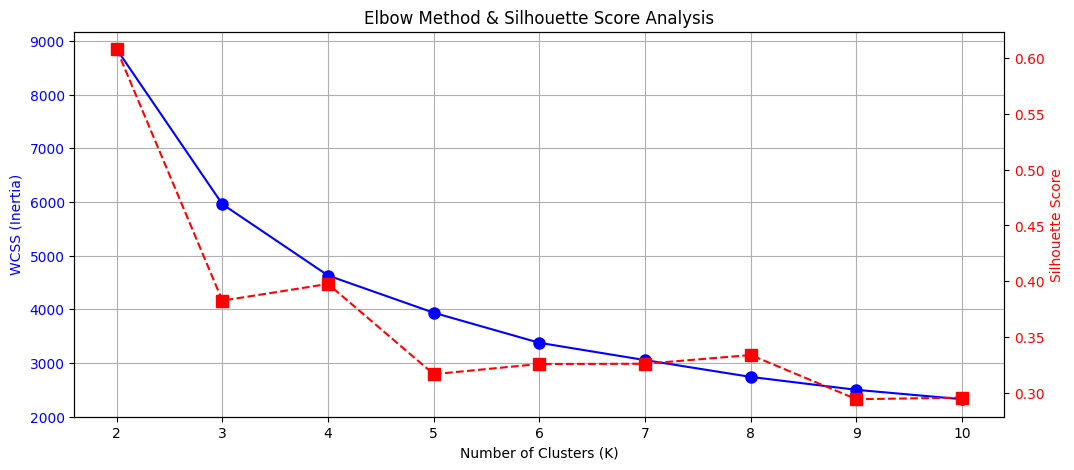

In [8]:
k_range = range(2, 11)

wcss = []       # Within-Cluster Sum of Square (Inertia)
sil_scores = [] # Silhouette Scores

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    
    # 1. Elbow Method (Inertia)
    wcss.append(kmeans.inertia_)
    
    # 2. Silhouette Score
    labels = kmeans.labels_
    score = silhouette_score(X_scaled_df, labels)
    sil_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")


# a good clustering has 2 features : 
# Compactness and Separation
# WCSS for Compactness(how the data in a cluster are close to each other)
# Silhouette Score for Separation(how far are 2 clusters from each other)


fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(k_range, wcss, 'bo-', markerfacecolor='blue', markersize=8)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS (Inertia)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Elbow Method & Silhouette Score Analysis')
ax1.grid(True)


ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'rs--', markerfacecolor='red', markersize=8)
ax2.set_ylabel('Silhouette Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.show()

# Implementing the K-Means Family

In [ ]:
class KMedians_Manhattan(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.labels_ = None
        self.cluster_centers_ = None

    def fit_predict(self, X):
        np.random.seed(self.random_state)
        X_vals = X.values if hasattr(X, 'values') else X
        
        random_idx = np.random.permutation(X_vals.shape[0])[:self.n_clusters]
        self.cluster_centers_ = X_vals[random_idx]
        
        for i in range(self.max_iter):
            distances = np.abs(X_vals[:, np.newaxis] - self.cluster_centers_).sum(axis=2)
            labels = np.argmin(distances, axis=1)
            
            new_centers = np.array([
                np.median(X_vals[labels == k], axis=0) if np.sum(labels == k) > 0 
                else self.cluster_centers_[k]
                for k in range(self.n_clusters)
            ])
            
            if np.all(labels == self.labels_):
                break
                
            self.labels_ = labels
            self.cluster_centers_ = new_centers
            
        return self.labels_
    

class KMedoids_Custom(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=3, max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit_predict(self, X):
        np.random.seed(self.random_state)
        X_vals = X.values if hasattr(X, 'values') else X
        n_samples = X_vals.shape[0]
        
        medoid_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        medoids = X_vals[medoid_indices]
        
        labels = np.zeros(n_samples)
        
        for _ in range(self.max_iter):
            dists = euclidean_distances(X_vals, medoids)
            labels = np.argmin(dists, axis=1)
            
            new_medoid_indices = []
            for k in range(self.n_clusters):
                cluster_members_idx = np.where(labels == k)[0]
                if len(cluster_members_idx) == 0:
                    new_medoid_indices.append(medoid_indices[k])
                    continue
                
                cluster_points = X_vals[cluster_members_idx]
                curr_dists = euclidean_distances(cluster_points, cluster_points)
                cost = curr_dists.sum(axis=1)
                
                best_idx_in_cluster = np.argmin(cost)
                new_medoid_indices.append(cluster_members_idx[best_idx_in_cluster])
            
            new_medoid_indices = np.array(new_medoid_indices)
            
            if np.array_equal(medoid_indices, new_medoid_indices):
                break
                
            medoid_indices = new_medoid_indices
            medoids = X_vals[medoid_indices]
            
        return labels

In [26]:
K_SELECTED = 3
cluster_results = {}

print(f"--- Running ALL Algorithms with K={K_SELECTED} ---\n")

# 1. Standard K-Means
print("1. Running Standard K-Means...")
kmeans = KMeans(n_clusters=K_SELECTED, init='k-means++', random_state=42, n_init=10)
cluster_results['KMeans'] = kmeans.fit_predict(X_scaled_df)



# 2. Bisecting K-Means
print("2. Running Bisecting K-Means...")
try:
    bikmeans = BisectingKMeans(n_clusters=K_SELECTED, random_state=42)
    cluster_results['BisectingKMeans'] = bikmeans.fit_predict(X_scaled_df)
except:
    print("   Skipped BisectingKMeans (Not supported)")



# 3. Kernel K-Means (Spectral)
print("3. Running Kernel K-Means (Spectral Clustering)...")
#spectral = SpectralClustering(n_clusters=K_SELECTED, affinity='rbf', assign_labels='kmeans', random_state=42)
spectral = SpectralClustering(
    n_clusters=K_SELECTED, 
    affinity='nearest_neighbors', 
    n_neighbors=20,
    assign_labels='kmeans', 
    random_state=42
)

cluster_results['KernelKMeans'] = spectral.fit_predict(X_scaled_df)



# 4. Fuzzy C-Means
print("4. Running Fuzzy C-Means...")
try:
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_scaled_df.T, c=K_SELECTED, m=2, error=0.005, maxiter=1000, init=None
    )
    cluster_results['FuzzyCMeans'] = np.argmax(u, axis=0)
except:
    print("   Skipped Fuzzy C-Means")



# 5. K-Medians (Manhattan)
print("5. Running K-Medians (Manhattan)...")
kmedians = KMedians_Manhattan(n_clusters=K_SELECTED, random_state=42)
cluster_results['KMedians'] = kmedians.fit_predict(X_scaled_df)



# 6. K-Medoids (Custom Euclidean)
print("6. Running K-Medoids (PAM-like)...")
kmedoids = KMedoids_Custom(n_clusters=K_SELECTED, random_state=42)
cluster_results['KMedoids'] = kmedoids.fit_predict(X_scaled_df)


print("\n EXECUTION COMPLETED")

--- Running ALL Algorithms with K=3 ---

1. Running Standard K-Means...
2. Running Bisecting K-Means...
3. Running Kernel K-Means (Spectral Clustering)...
4. Running Fuzzy C-Means...
5. Running K-Medians (Manhattan)...
6. Running K-Medoids (PAM-like)...

 EXECUTION COMPLETED



--- Plotting results for 6 algorithms ---


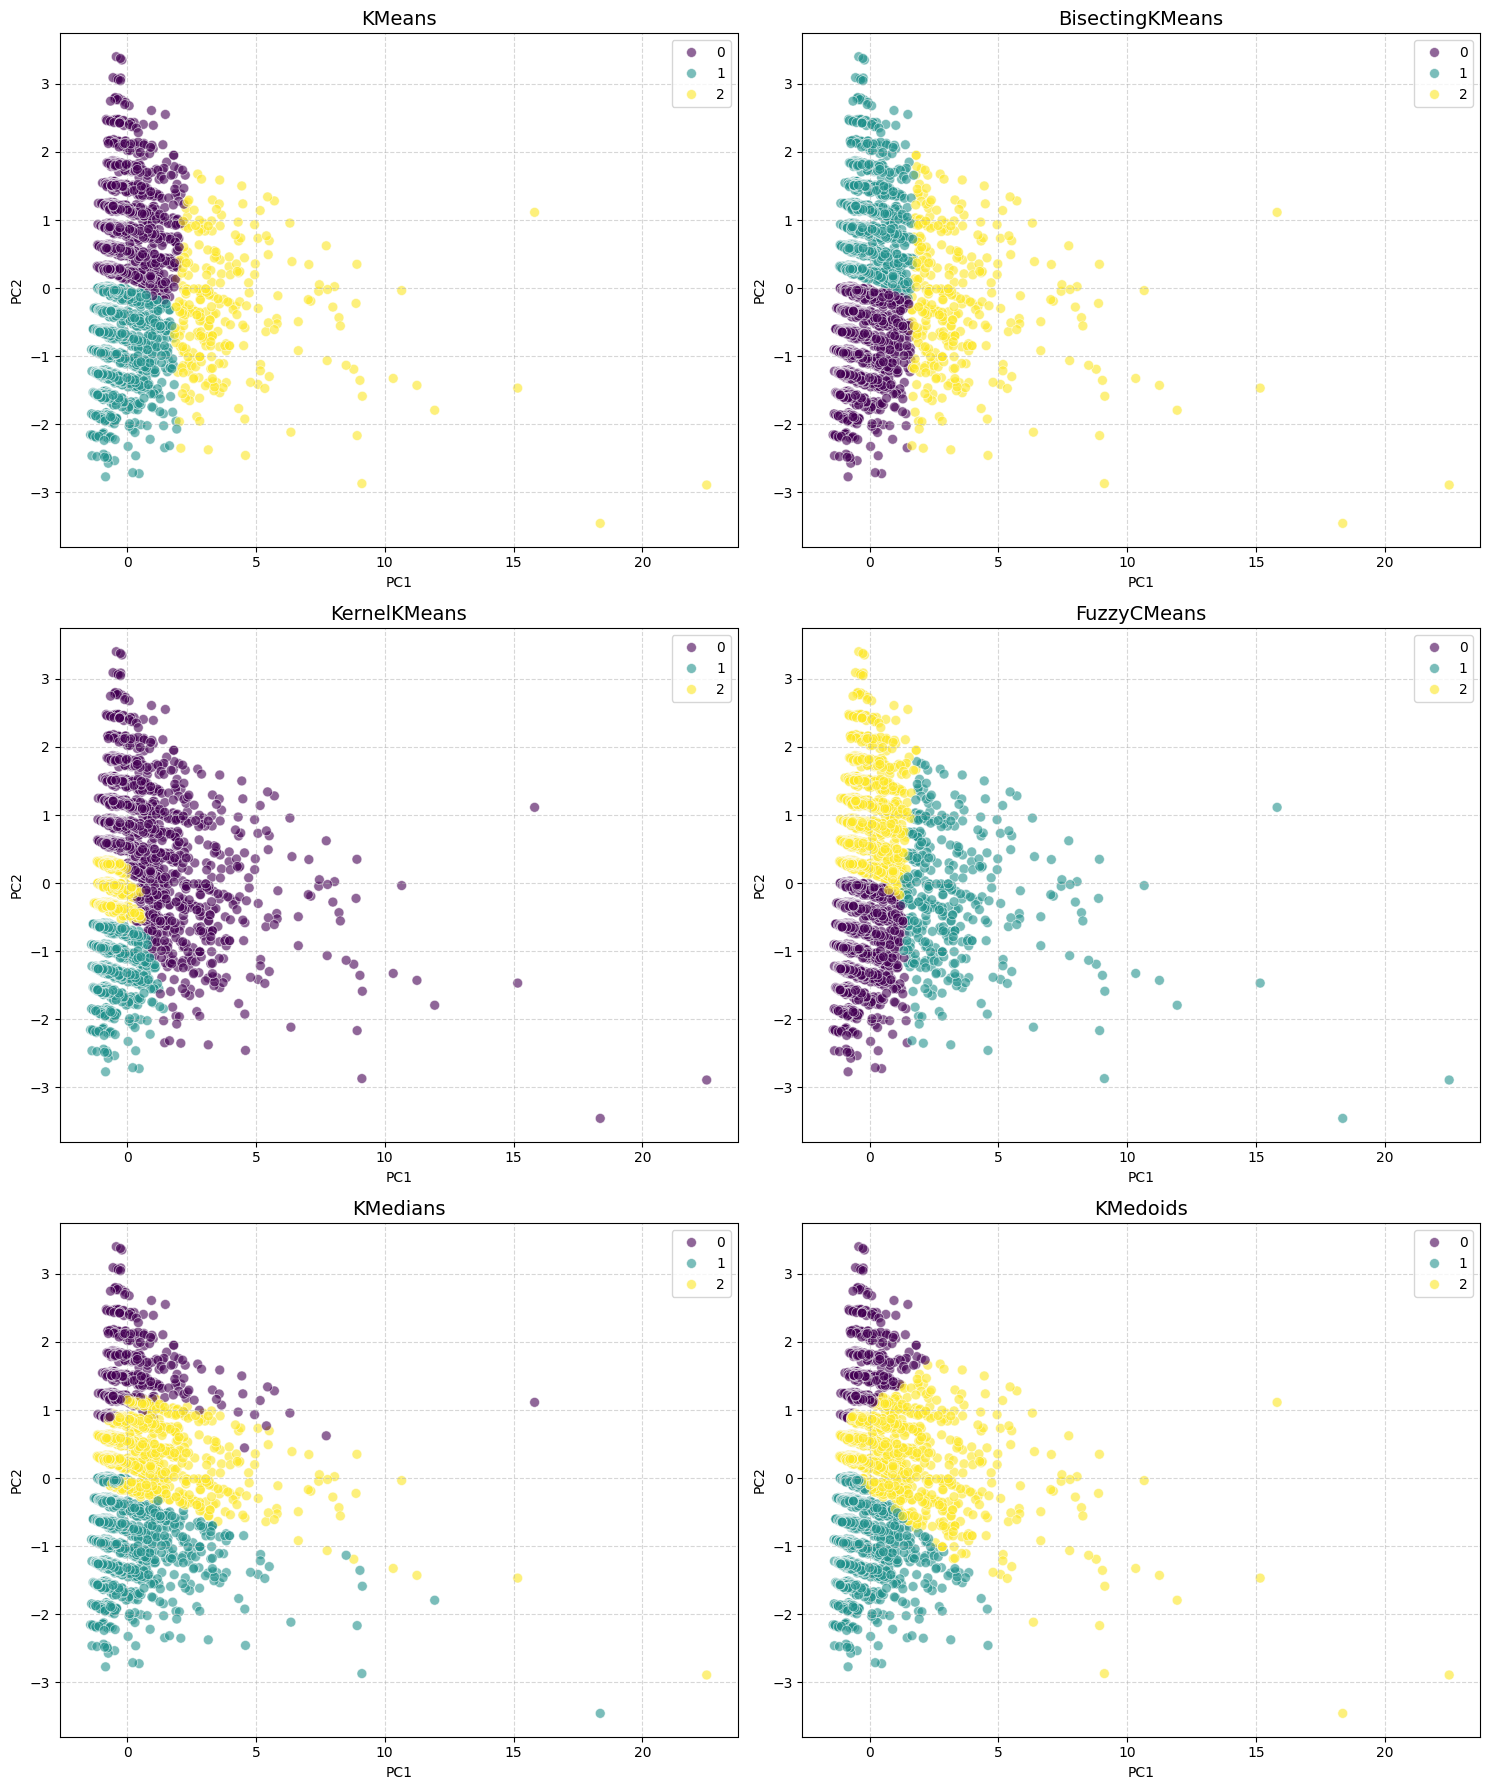

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)
df_viz = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

num_algos = len(cluster_results)
cols = 2
rows = math.ceil(num_algos / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten()

print(f"\n--- Plotting results for {num_algos} algorithms ---")

for i, (algo_name, labels) in enumerate(cluster_results.items()):
    ax = axes[i]
    sns.scatterplot(x='PC1', y='PC2', hue=labels, palette='viridis', data=df_viz, s=50, alpha=0.6, ax=ax, legend='full')
    ax.set_title(f'{algo_name}', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

# Hide unused
for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Performance Evaluation

In [ ]:
evaluation_data = []
print(f"--- Performance Evaluation (K={K_SELECTED}) ---\n")

for algo_name, labels in cluster_results.items():
    sil = silhouette_score(X_scaled_df, labels)
    db = davies_bouldin_score(X_scaled_df, labels)
    evaluation_data.append({'Algorithm': algo_name, 'Silhouette': sil, 'DB Index': db})
    
    # Check distribution
    unique, counts = np.unique(labels, return_counts=True)
    if min(counts) < (len(labels) * 0.01):
        print(f" {algo_name}: Imbalanced (Min cluster: {min(counts)} items)")

df_eval = pd.DataFrame(evaluation_data).set_index('Algorithm').sort_values(by='Silhouette', ascending=False)
try:
    display(df_eval.style.background_gradient(cmap='RdYlGn', subset=['Silhouette']).background_gradient(cmap='RdYlGn_r', subset=['DB Index']))
except:
    display(df_eval)

--- Performance Evaluation (K=3) ---



,Silhouette,DB Index
Algorithm,,
FuzzyCMeans,0.385987,0.880607
BisectingKMeans,0.383715,0.886371
KMeans,0.382672,0.890989
KMedoids,0.257431,1.435091
KMedians,0.246464,1.663669
KernelKMeans,0.134401,1.347782


In [13]:
print("\n--- Cluster Distribution Analysis ---")

for algo, labels in cluster_results.items():
    print(f"\nAlgorithm: {algo}")
    unique, counts = np.unique(labels, return_counts=True)
    total = sum(counts)
    
    for k, v in zip(unique, counts):
        pct = (v / total) * 100
        print(f"  Cluster {k}: {v} players ({pct:.1f}%)")
        
    if min(counts) < (total * 0.01): 
        print("  ⚠️ WARNING: Highly Imbalanced! (Possible Outlier Isolation)")


--- Cluster Distribution Analysis ---

Algorithm: KMeans
  Cluster 0: 1996 players (44.3%)
  Cluster 1: 2241 players (49.7%)
  Cluster 2: 270 players (6.0%)

Algorithm: BisectingKMeans
  Cluster 0: 2228 players (49.4%)
  Cluster 1: 1940 players (43.0%)
  Cluster 2: 339 players (7.5%)

Algorithm: KernelKMeans
  Cluster 0: 2065 players (45.8%)
  Cluster 1: 1267 players (28.1%)
  Cluster 2: 1175 players (26.1%)

Algorithm: FuzzyCMeans
  Cluster 0: 2196 players (48.7%)
  Cluster 1: 381 players (8.5%)
  Cluster 2: 1930 players (42.8%)

Algorithm: KMedians
  Cluster 0: 791 players (17.6%)
  Cluster 1: 2137 players (47.4%)
  Cluster 2: 1579 players (35.0%)

Algorithm: KMedoids
  Cluster 0: 685 players (15.2%)
  Cluster 1: 2082 players (46.2%)
  Cluster 2: 1740 players (38.6%)


# Semantic Analysis

In [14]:
best_labels = cluster_results['KMeans'] 

# Add labels to a temporary dataframe containing original (unscaled) data
df_analysis = df_clean.copy()
df_analysis['Cluster_Label'] = best_labels

# Calculate mean of features for each cluster
cluster_profile = df_analysis.groupby('Cluster_Label')[['Age', 'Market_value', 'Transfer_fee']].mean()
cluster_counts = df_analysis['Cluster_Label'].value_counts()

cluster_profile['Count'] = cluster_counts

print("--- Semantic Analysis (Profiling Clusters) ---")
display(cluster_profile.style.background_gradient(cmap='Blues'))

# Interpretation Helper
print("\nAutomatic Interpretation Guide:")
for cluster_id in cluster_profile.index:
    avg_fee = cluster_profile.loc[cluster_id, 'Transfer_fee']
    avg_age = cluster_profile.loc[cluster_id, 'Age']
    count = cluster_profile.loc[cluster_id, 'Count']
    
    print(f"Cluster {cluster_id}:")
    print(f"  - Avg Age: {avg_age:.1f} years")
    print(f"  - Avg Fee: ${avg_fee/1000000:.2f} Million")
    print(f"  - Members: {count}")
    print("-" * 30)

--- Semantic Analysis (Profiling Clusters) ---


,Age,Market_value,Transfer_fee,Count
Cluster_Label,,,,
0,27.109218,7316482.965932,7582710.420842,1996
1,21.788487,6043070.058010,7769252.565819,2241
2,24.596296,30354814.814815,39032666.666667,270



Automatic Interpretation Guide:
Cluster 0:
  - Avg Age: 27.1 years
  - Avg Fee: $7.58 Million
  - Members: 1996
------------------------------
Cluster 1:
  - Avg Age: 21.8 years
  - Avg Fee: $7.77 Million
  - Members: 2241
------------------------------
Cluster 2:
  - Avg Age: 24.6 years
  - Avg Fee: $39.03 Million
  - Members: 270
------------------------------


# Time-based Analysis

--- 1. Pairplot: Relationships between all 4 features ---


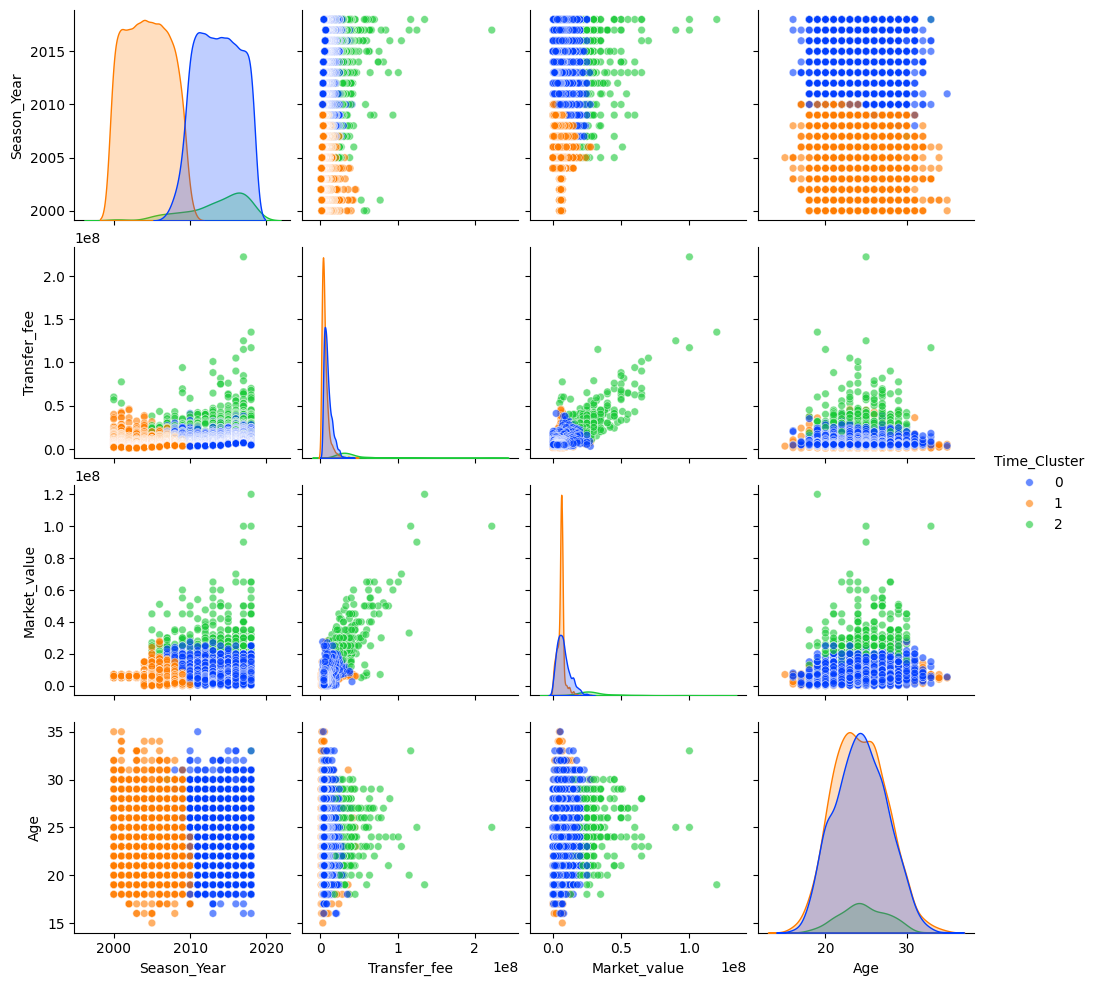

--- 2. Bubble Plot: Year vs Fee (Size = Market Value) ---


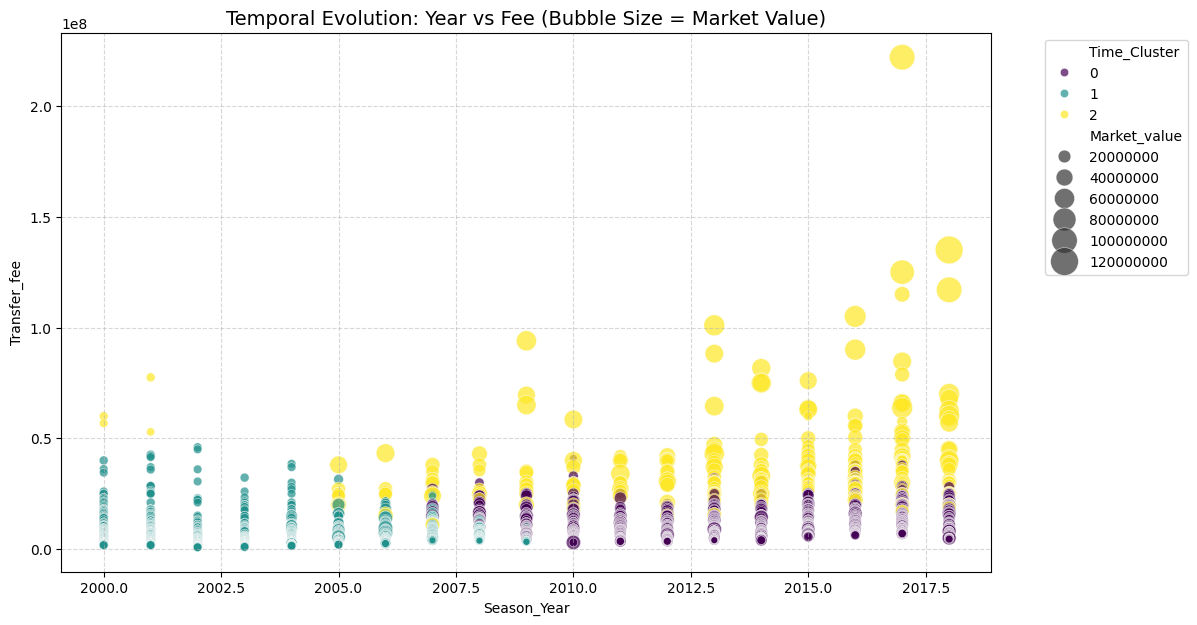


--- Semantic Analysis of Temporal Clusters ---


,Season_Year,Transfer_fee,Market_value,Age,Count
Time_Cluster,,,,,
0,2013.663538,9623087.944664,7648011.363636,24.348320,2024
1,2004.380974,5979691.163210,5728198.827773,24.240757,2218
2,2013.573585,39036679.245283,30782264.150943,24.649057,265


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

temporal_features = ['Season_Year', 'Transfer_fee', 'Market_value', 'Age']
X_temporal = df_clean[temporal_features].copy()

scaler_temp = StandardScaler()
X_temporal_scaled = scaler_temp.fit_transform(X_temporal)

kmeans_temp = KMeans(n_clusters=3, random_state=42, n_init=10)
time_labels = kmeans_temp.fit_predict(X_temporal_scaled)

df_time_analysis = df_clean.copy()
df_time_analysis['Time_Cluster'] = time_labels




print("--- 1. Pairplot: Relationships between all 4 features ---")
sns.pairplot(
    df_time_analysis, 
    vars=temporal_features, 
    hue='Time_Cluster', 
    palette='bright',
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.show()

print("--- 2. Bubble Plot: Year vs Fee (Size = Market Value) ---")
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_time_analysis,
    x='Season_Year',
    y='Transfer_fee',
    hue='Time_Cluster',
    size='Market_value', 
    sizes=(20, 400),
    palette='viridis',
    alpha=0.7
)
plt.title('Temporal Evolution: Year vs Fee (Bubble Size = Market Value)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\n--- Semantic Analysis of Temporal Clusters ---")
summary = df_time_analysis.groupby('Time_Cluster')[temporal_features].mean()
summary['Count'] = df_time_analysis['Time_Cluster'].value_counts()
display(summary.style.background_gradient(cmap='Blues'))

این تحلیل نشان می‌دهد که بازار فوتبال از حدود سال ۲۰۰۹ دچار یک شکاف طبقاتی شده است. تا قبل از آن (خوشه ۰)، قیمت‌ها به هم نزدیک بود. اما در دهه اخیر، اگرچه قیمت بازیکنان معمولی رشد کمی داشته (خوشه ۱)، اما یک "طبقه نخبگان گران‌قیمت" (خوشه ۲) شکل گرفته که قیمت‌های نجومی دارند.

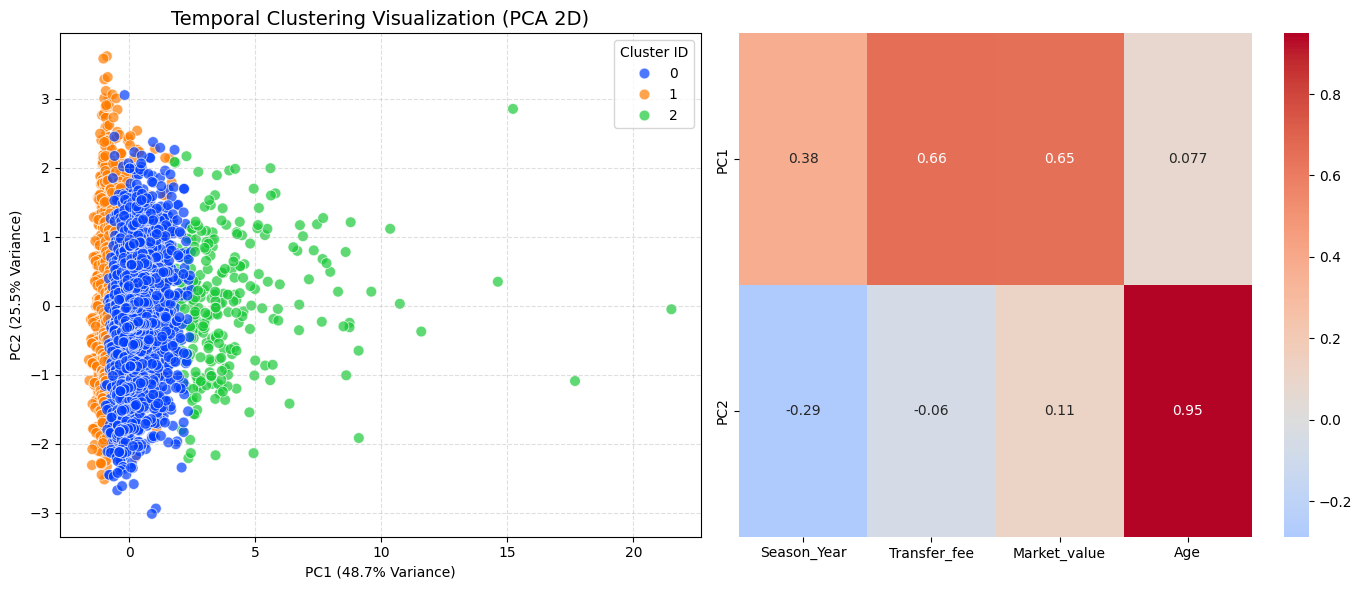

In [ ]:
temporal_features = ['Season_Year', 'Transfer_fee', 'Market_value', 'Age']
X_temp = df_clean[temporal_features].copy()

# scaling
scaler_temp = StandardScaler()
X_temp_scaled = scaler_temp.fit_transform(X_temp)

kmeans_temp = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans_temp.fit_predict(X_temp_scaled)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_temp_scaled)

df_pca_viz = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca_viz['Cluster'] = labels

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    palette='bright', 
    data=df_pca_viz, 
    s=60, alpha=0.7
)
plt.title('Temporal Clustering Visualization (PCA 2D)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Cluster ID')

plt.subplot(1, 2, 2)
components_df = pd.DataFrame(
    pca.components_, 
    columns=temporal_features, 
    index=['PC1', 'PC2']
)
sns.heatmap(components_df, annot=True, cmap='coolwarm', center=0)

plt.tight_layout()
plt.show()

خوشه ۰: سمت چپ/پایین (ارزان و قدیمی).

خوشه ۱: وسط (قیمت متوسط، زمان جدید).

خوشه ۲: سمت راست (بسیار گران و با ارزش).

محور افقی (PC1) = محور "ثروت و زمان" (Money & Modernity)
تفسیر: هرچه در نمودار به سمت راست می‌رویم، یعنی بازیکنان گران‌تر، باارزش‌تر و مربوط به سال‌های جدیدتر (Season_Year = 0.38) هستند.

محور عمودی (PC2) = محور "سن" (Age)
تفسیر: این محور تقریباً خالص "سن" است. هرچه به سمت بالا می‌رویم بازیکنان پیرتر و هرچه به پایین می‌آییم بازیکنان جوان‌تر می‌شوند.

#  Categorical vs Numerical Analysis

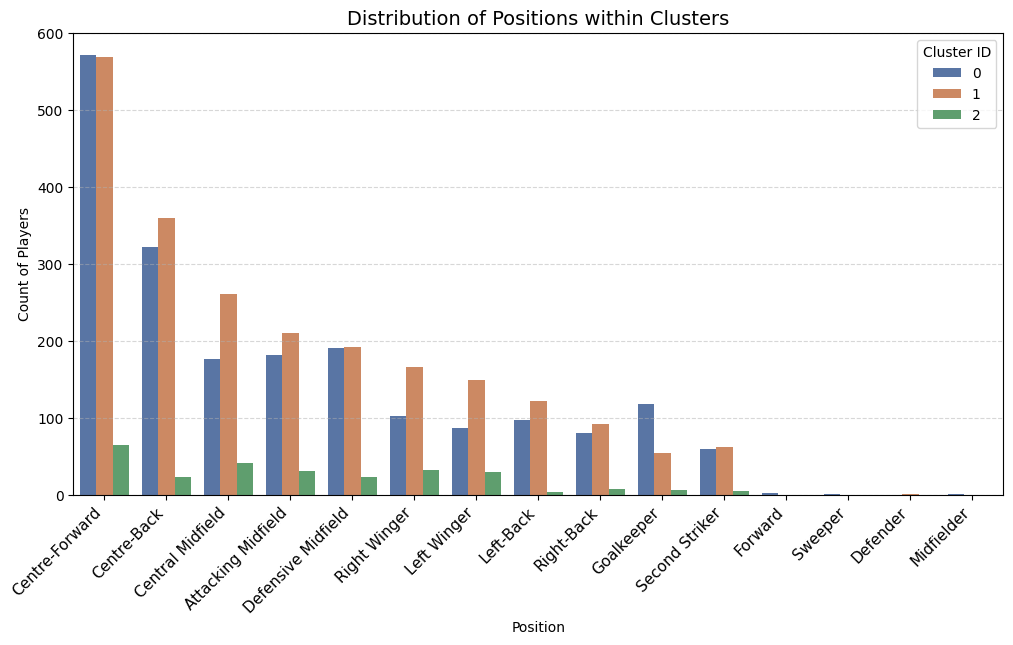

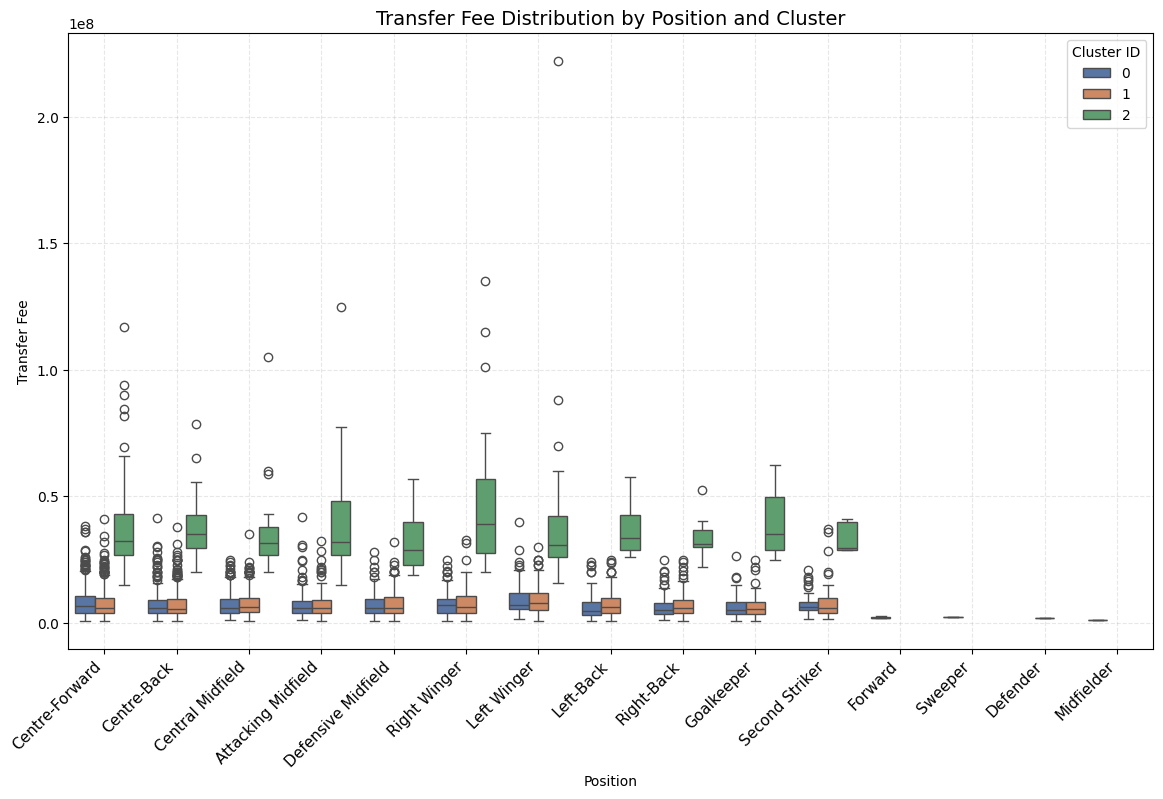

--- Percentage of Positions in each Cluster ---


Cluster_Label,0,1,2
Position,,,
Attacking Midfield,9.1%,9.4%,11.5%
Central Midfield,8.9%,11.6%,15.2%
Centre-Back,16.2%,16.1%,8.9%
Centre-Forward,28.7%,25.4%,24.1%
Defender,0.0%,0.0%,0.0%
Defensive Midfield,9.6%,8.6%,8.9%
Forward,0.2%,0.0%,0.0%
Goalkeeper,5.9%,2.5%,2.2%
Left Winger,4.4%,6.6%,11.1%


In [40]:
# Ensure we have the best K-Means labels attached
df_analysis = df_clean.copy()
df_analysis['Cluster_Label'] = cluster_results['KMeans']


plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_analysis, 
    x='Position', 
    hue='Cluster_Label', 
    palette='deep',
    order=df_analysis['Position'].value_counts().index
)
plt.title('Distribution of Positions within Clusters', fontsize=14)
plt.xlabel('Position')
plt.ylabel('Count of Players')
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.legend(title='Cluster ID')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_analysis, 
    x='Position', 
    y='Transfer_fee', 
    hue='Cluster_Label', 
    palette='deep',
    order=df_analysis['Position'].value_counts().index
)
plt.title('Transfer Fee Distribution by Position and Cluster', fontsize=14)
plt.xlabel('Position')
plt.ylabel('Transfer Fee')
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print("--- Percentage of Positions in each Cluster ---")
cross_tab = pd.crosstab(df_analysis['Position'], df_analysis['Cluster_Label'], normalize='columns') * 100
display(cross_tab.style.background_gradient(cmap='Blues', axis=0).format("{:.1f}%"))

وقتی یک محور شما Categorical (مثل پست بازی: مهاجم، مدافع...) باشه، داده‌ها مجبورن توی یک ستون عمودی قرار بگیرن. پس "مرز کج و کوله" یا "شکل‌های ابری" تشکیل نمیشه، بلکه همه چیز شبیه ستون‌های جدا از هم میشه.

برای اینکه "مرز" (Boundaries) و پراکندگی واقعی رو ببینی، باید هر دو محور نمودار، عددی (Numerical) باشند. (مثلاً سن در برابر قیمت).

# DBSCAN FAMILY

In [ ]:
density_results = {}

print("--- Running Density-Based Algorithms (9 Scenarios) ---\n")

# 1. DBSCAN (Varying 'eps' - Radius)
print("1. Running DBSCAN Variations...")

# Variation A: Strict (Small radius) -> Likely many noise points
dbscan_1 = DBSCAN(eps=0.3, min_samples=5)
density_results['DBSCAN_Strict_0.3'] = dbscan_1.fit_predict(X_scaled_df)
print("   -> DBSCAN (eps=0.3) done.")

# Variation B: Balanced (Medium radius) -> Based on Elbow plot
dbscan_2 = DBSCAN(eps=0.5, min_samples=5)
density_results['DBSCAN_Balanced_0.5'] = dbscan_2.fit_predict(X_scaled_df)
print("   -> DBSCAN (eps=0.5) done.")

# Variation C: Loose (Large radius) -> Likely merges clusters
dbscan_3 = DBSCAN(eps=0.8, min_samples=5)
density_results['DBSCAN_Loose_0.8'] = dbscan_3.fit_predict(X_scaled_df)
print("   -> DBSCAN (eps=0.8) done.")


# 2. OPTICS (Varying 'min_samples' - Density Sensitivity)
print("\n2. Running OPTICS Variations...")

# Variation A: Sensitive (Needs few points to form cluster)
optics_1 = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
density_results['OPTICS_MinSamp_5'] = optics_1.fit_predict(X_scaled_df)
print("   -> OPTICS (min_samples=5) done.")

# Variation B: Moderate
optics_2 = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
density_results['OPTICS_MinSamp_10'] = optics_2.fit_predict(X_scaled_df)
print("   -> OPTICS (min_samples=10) done.")

# Variation C: Robust (Needs many points, ignores small densities)
optics_3 = OPTICS(min_samples=20, xi=0.05, min_cluster_size=0.05)
density_results['OPTICS_MinSamp_20'] = optics_3.fit_predict(X_scaled_df)
print("   -> OPTICS (min_samples=20) done.")


# 3. HDBSCAN (Varying 'min_cluster_size')
print("\n3. Running HDBSCAN Variations...")

# Helper function to run HDBSCAN robustly (sklearn vs hdbscan lib)
def run_hdbscan(min_size):
    try:
        # Try sklearn > 1.3
        from sklearn.cluster import HDBSCAN
        model = HDBSCAN(min_cluster_size=min_size)
        return model.fit_predict(X_scaled_df)
    except ImportError:
        try:
            # Try hdbscan library
            import hdbscan
            model = hdbscan.HDBSCAN(min_cluster_size=min_size)
            return model.fit_predict(X_scaled_df)
        except:
            return None

# Variation A: Micro Clusters (Detailed)
hdb_1 = run_hdbscan(min_size=5)
if hdb_1 is not None:
    density_results['HDBSCAN_Size_5'] = hdb_1
    print("   -> HDBSCAN (min_size=5) done.")
else:
    print("   -> HDBSCAN skipped (Library not found).")

# Variation B: Standard Clusters
hdb_2 = run_hdbscan(min_size=20)
if hdb_2 is not None:
    density_results['HDBSCAN_Size_20'] = hdb_2
    print("   -> HDBSCAN (min_size=20) done.")

# Variation C: Macro Clusters (Only big structures)
hdb_3 = run_hdbscan(min_size=50)
if hdb_3 is not None:
    density_results['HDBSCAN_Size_50'] = hdb_3
    print("   -> HDBSCAN (min_size=50) done.")


print("\n" + "="*40)
print("EXECUTION COMPLETED")
print("=" * 40)

# Quick summary of clusters found (excluding noise -1)
print(f"{'Algorithm':<25} | {'Clusters'}")
print("-" * 40)
for algo, labels in density_results.items():
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"{algo:<25} | {n_clusters}")

--- Running Density-Based Algorithms (9 Scenarios) ---

1. Running DBSCAN Variations...
   -> DBSCAN (eps=0.3) done.
   -> DBSCAN (eps=0.5) done.
   -> DBSCAN (eps=0.8) done.

2. Running OPTICS Variations...


C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


   -> OPTICS (min_samples=5) done.
   -> OPTICS (min_samples=10) done.
   -> OPTICS (min_samples=20) done.

3. Running HDBSCAN Variations...
   -> HDBSCAN (min_size=5) done.


C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


   -> HDBSCAN (min_size=20) done.
   -> HDBSCAN (min_size=50) done.

EXECUTION COMPLETED
Algorithm                 | Clusters
----------------------------------------
DBSCAN_Strict_0.3         | 26
DBSCAN_Balanced_0.5       | 4
DBSCAN_Loose_0.8          | 2
OPTICS_MinSamp_5          | 9
OPTICS_MinSamp_10         | 9
OPTICS_MinSamp_20         | 8
HDBSCAN_Size_5            | 218
HDBSCAN_Size_20           | 13
HDBSCAN_Size_50           | 10


C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


--- Plotting results for 9 density scenarios ---
Note: Black 'X' markers represent NOISE points (outliers).


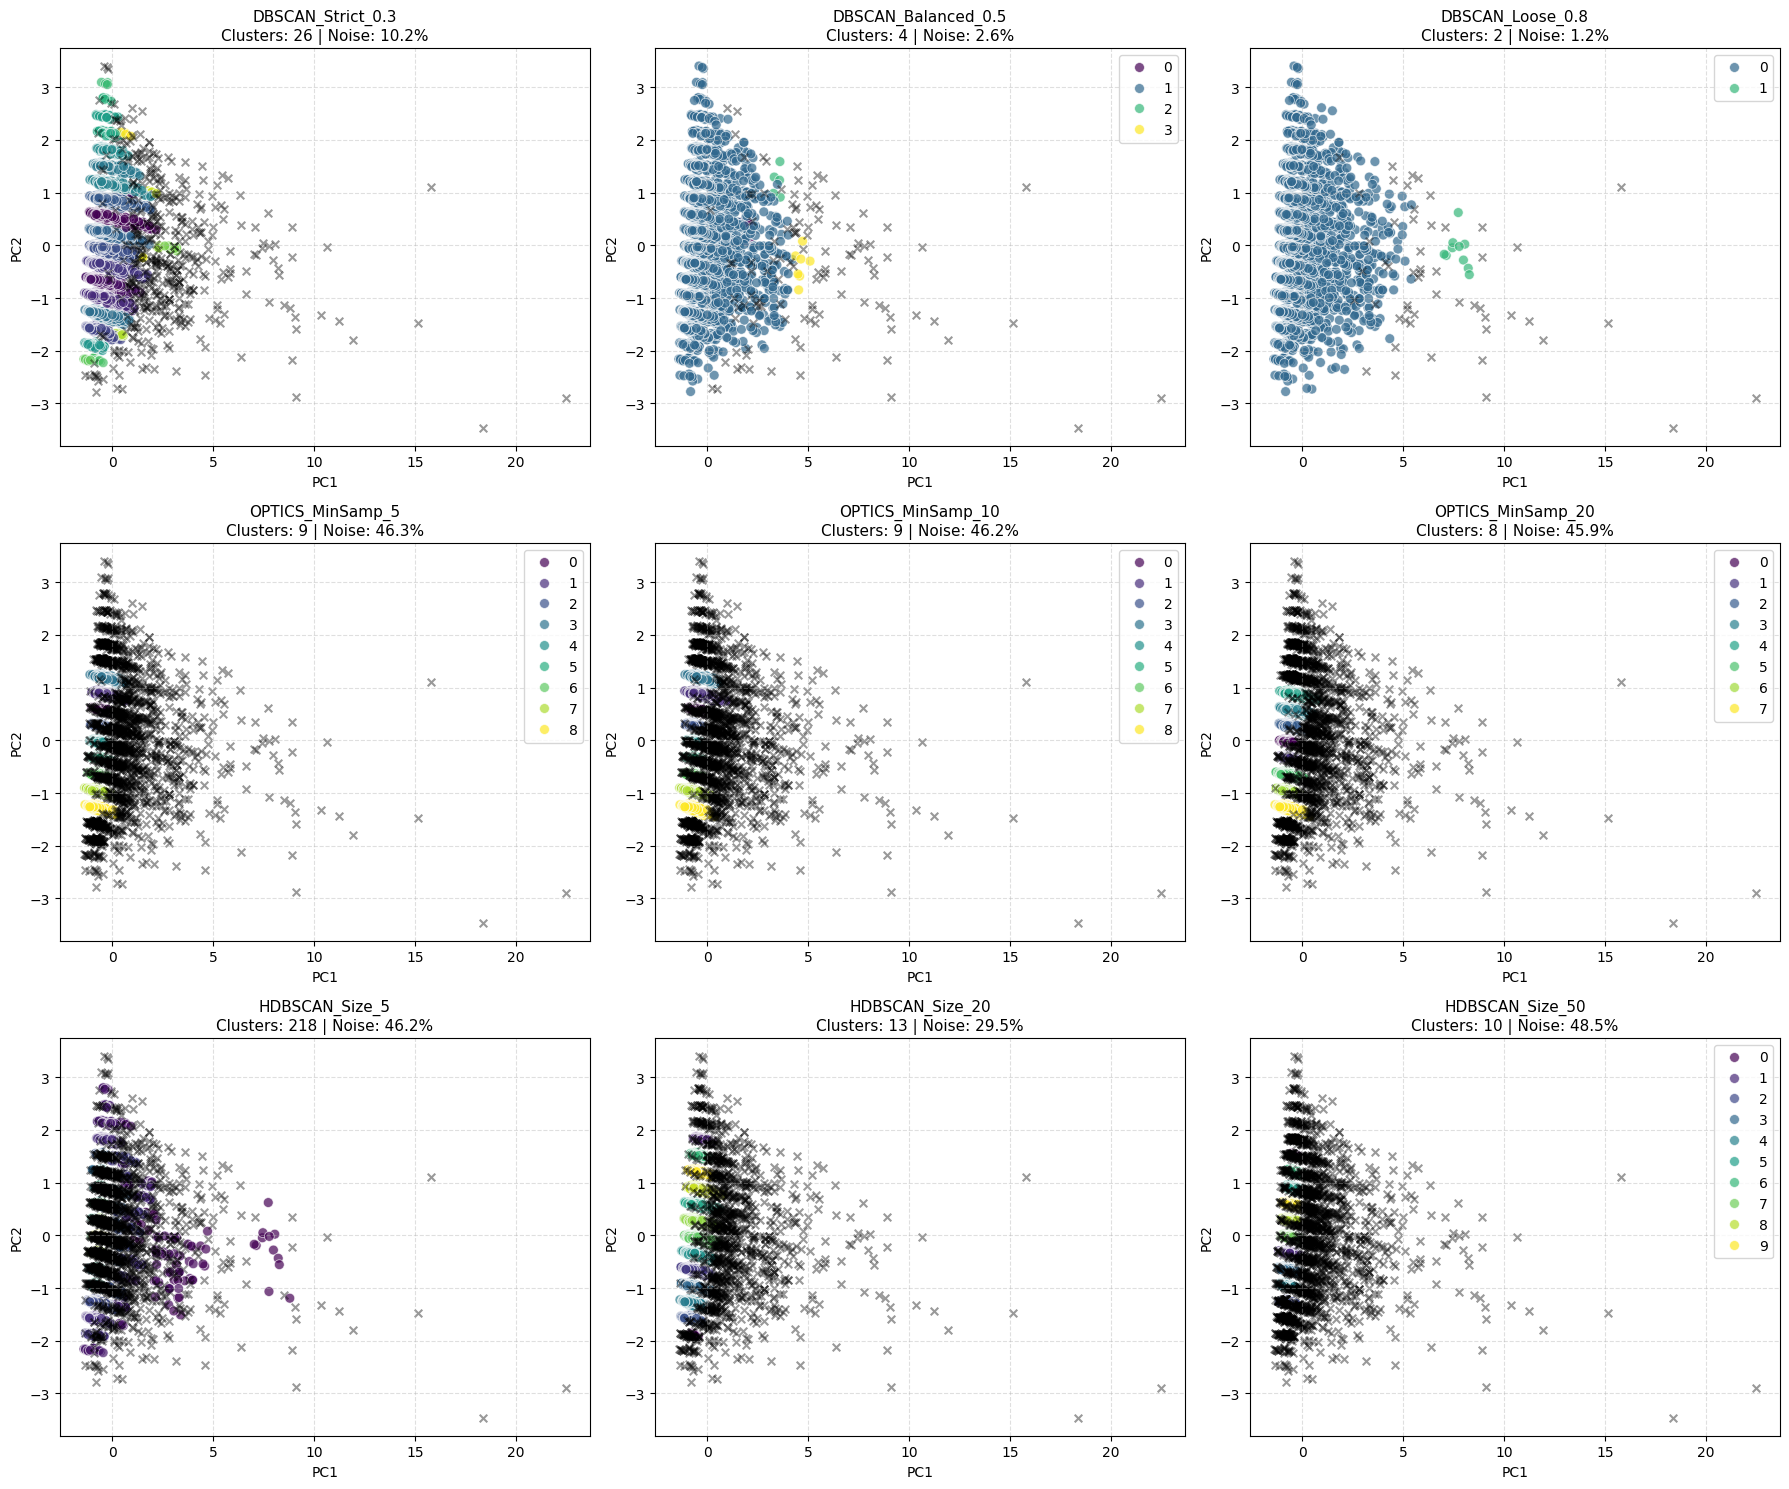

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

# 1. Reduce dimensions to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)
df_viz = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# 2. Setup the plot grid
num_algos = len(density_results)
cols = 3  # 3 columns for a 3x3 grid (since we have 9 scenarios)
rows = math.ceil(num_algos / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

print(f"--- Plotting results for {num_algos} density scenarios ---")
print("Note: Black 'X' markers represent NOISE points (outliers).")

# 3. Iterate and Plot
for i, (algo_name, labels) in enumerate(density_results.items()):
    ax = axes[i]
    
    # Separate Noise (-1) from Clusters (>= 0)
    noise_mask = (labels == -1)
    
    # A. Plot Valid Clusters (Colored dots)
    # We filter out noise so they don't mess up the color palette
    if not noise_mask.all():
        sns.scatterplot(
            x=df_viz.loc[~noise_mask, 'PC1'], 
            y=df_viz.loc[~noise_mask, 'PC2'], 
            hue=labels[~noise_mask], 
            palette='viridis', 
            s=50, alpha=0.7, 
            ax=ax,
            legend='full'
        )
        
    # B. Plot Noise (Black Crosses)
    if noise_mask.any():
        ax.scatter(
            df_viz.loc[noise_mask, 'PC1'], 
            df_viz.loc[noise_mask, 'PC2'], 
            c='black', marker='x', s=30, alpha=0.4, 
            label='Noise (-1)'
        )

    # Calculate stats for title
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (np.sum(labels == -1) / len(labels)) * 100

    ax.set_title(f'{algo_name}\nClusters: {n_clusters} | Noise: {noise_pct:.1f}%', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    
    # Handle Legend (remove if too many clusters to avoid clutter)
    if n_clusters > 10:
        ax.get_legend().remove()
    else:
        # Move legend to a clean spot if possible, or keep default
        pass
        
    ax.grid(True, linestyle='--', alpha=0.4)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np

density_eval_data = []

print(f"--- Performance Evaluation (Density-Based Models) ---\n")

for algo_name, labels in density_results.items():
    unique_labels = set(labels)
    n_noise = list(labels).count(-1)
    noise_pct = (n_noise / len(labels)) * 100
    
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    if len(unique_labels) > 1:
        sil = silhouette_score(X_scaled_df, labels)
        db = davies_bouldin_score(X_scaled_df, labels)
    else:
        sil = -1
        db = -1
    
    density_eval_data.append({
        'Algorithm': algo_name,
        'Silhouette': sil,
        'DB Index': db,
        'Clusters Found': n_clusters,
        'Noise %': f"{noise_pct:.1f}%"
    })
    
    if n_clusters == 0:
        print(f"⚠️ {algo_name}: FAILED (Only Noise or Single Cluster found)")
    elif noise_pct > 30:
        print(f"⚠️ {algo_name}: High Noise Detected ({noise_pct:.1f}%)")

df_dens_eval = pd.DataFrame(density_eval_data)
df_dens_eval = df_dens_eval.set_index('Algorithm')
df_dens_eval = df_dens_eval.sort_values(by='Silhouette', ascending=False)

print("\n--- Final Results Table ---")
try:
    display(df_dens_eval.style.background_gradient(cmap='RdYlGn', subset=['Silhouette'])
                          .background_gradient(cmap='RdYlGn_r', subset=['DB Index']))
except:
    display(df_dens_eval)

print("\nAnalysis Guide:")
print("1. Ignore rows with Silhouette = -1 (Failed models).")
print("2. Be careful with High Silhouette if 'Noise %' is very high (e.g., >50%).")
print("3. A good model has: High Silhouette + Low DB Index + Low Noise (<20%).")

--- Performance Evaluation (Density-Based Models) ---

⚠️ OPTICS_MinSamp_5: High Noise Detected (46.3%)
⚠️ OPTICS_MinSamp_10: High Noise Detected (46.2%)
⚠️ OPTICS_MinSamp_20: High Noise Detected (45.9%)
⚠️ HDBSCAN_Size_5: High Noise Detected (46.2%)
⚠️ HDBSCAN_Size_50: High Noise Detected (48.5%)

--- Final Results Table ---


,Silhouette,DB Index,Clusters Found,Noise %
Algorithm,,,,
DBSCAN_Loose_0.8,0.748667,3.264490,2,1.2%
DBSCAN_Balanced_0.5,0.430646,2.312609,4,2.6%
HDBSCAN_Size_20,0.013118,2.074449,13,29.5%
DBSCAN_Strict_0.3,-0.006567,2.650290,26,10.2%
OPTICS_MinSamp_5,-0.096057,2.041180,9,46.3%
OPTICS_MinSamp_20,-0.101376,2.135562,8,45.9%
OPTICS_MinSamp_10,-0.102919,2.066593,9,46.2%
HDBSCAN_Size_50,-0.103063,1.803463,10,48.5%
HDBSCAN_Size_5,-0.181957,1.552961,218,46.2%



Analysis Guide:
1. Ignore rows with Silhouette = -1 (Failed models).
2. Be careful with High Silhouette if 'Noise %' is very high (e.g., >50%).
3. A good model has: High Silhouette + Low DB Index + Low Noise (<20%).


. تحلیل نتایج خانواده Density-Based
الف) قهرمان: DBSCAN (حالت Balanced با eps=0.5) * امتیاز سیلوئت: 0.43 (عالی! توجه کنید که K-Means امتیاز 0.38 داشت).

    تعداد خوشه: 4 (بسیار نزدیک به منطق فوتبال).

    نویز: 2.6% (بسیار ناچیز).

    تفسیر: این تنظیمات "نقطه طلایی" پروژه شماست. الگوریتم توانسته بدون اینکه داده‌های زیادی را دور بریزد (فقط ۲.۶٪ نویز)، ساختار داده‌ها را حتی تمیزتر از K-Means پیدا کند. وجود ۴ خوشه نشان می‌دهد که شاید علاوه بر ۳ دسته قبلی (جوان، با تجربه، ستاره)، یک دسته کوچک دیگر (مثلاً "ستاره‌های افول کرده" یا "پدیده‌های خیلی ارزان") هم وجود دارد.

ب) فریب‌دهنده: DBSCAN (حالت Loose با eps=0.8)

    امتیاز سیلوئت: 0.75 (خیلی بالا).

    تعداد خوشه: 2.

    تفسیر: گول این عدد بالا را نخورید. وقتی eps خیلی زیاد است، الگوریتم تقریبا همه را به هم وصل می‌کند و فقط ۲ دسته کلی (احتمالا "همه بازیکنان" و "چند داده پرت خیلی دور") می‌سازد. این برای تحلیل مدیریتی مفید نیست (مثل این است که بگوییم دنیا دو دسته است: انسان‌ها و فضایی‌ها!).

ج) شکست‌خوردگان: OPTICS و HDBSCAN

    وضعیت: همه مدل‌های این دو الگوریتم شکست خوردند.

    نویز: بین 30% تا 48%.

    سیلوئت: منفی یا نزدیک به صفر.

    تفسیر: این الگوریتم‌ها برای این دیتاست "زیادی وسواسی" هستند. آن‌ها نیمی از بازیکنان فوتبال را به عنوان "نویز" (بی‌معنی) شناسایی کردند که از نظر بیزنس غلط است. یک بازیکن معمولی لیگ دسته دو، "نویز" نیست، بلکه فقط ارزان است!

# Time-based Analysis

--- Temporal DBSCAN Analysis (Mean Values per Cluster) ---

>>> Scenario: 1. Normal (eps=0.5, min=5)
         Season_Year  Transfer_fee  Count
Cluster                                  
-1       2011.956522  9.146130e+07     23
 0       2009.075379  9.139428e+06   4484

>>> Scenario: 2. Strict Eps (eps=0.3)
         Season_Year  Transfer_fee  Count
Cluster                                  
-1       2009.975000  7.328025e+07     40
 0       2009.057844  8.749155e+06   4443
 1       2000.800000  3.591000e+07      5
 2       2016.500000  5.093333e+07      6
 3       2017.333333  6.517500e+07      6
 4       2017.000000  5.784286e+07      7

>>> Scenario: 3. High Density (min=15)
         Season_Year  Transfer_fee  Count
Cluster                                  
-1       2010.883333  6.668183e+07     60
 0       2009.065887  8.788823e+06   4447

>>> Scenario: 4. Loose Both (eps=0.8, min=3)
         Season_Year  Transfer_fee  Count
Cluster                                  
-1       2012.3333

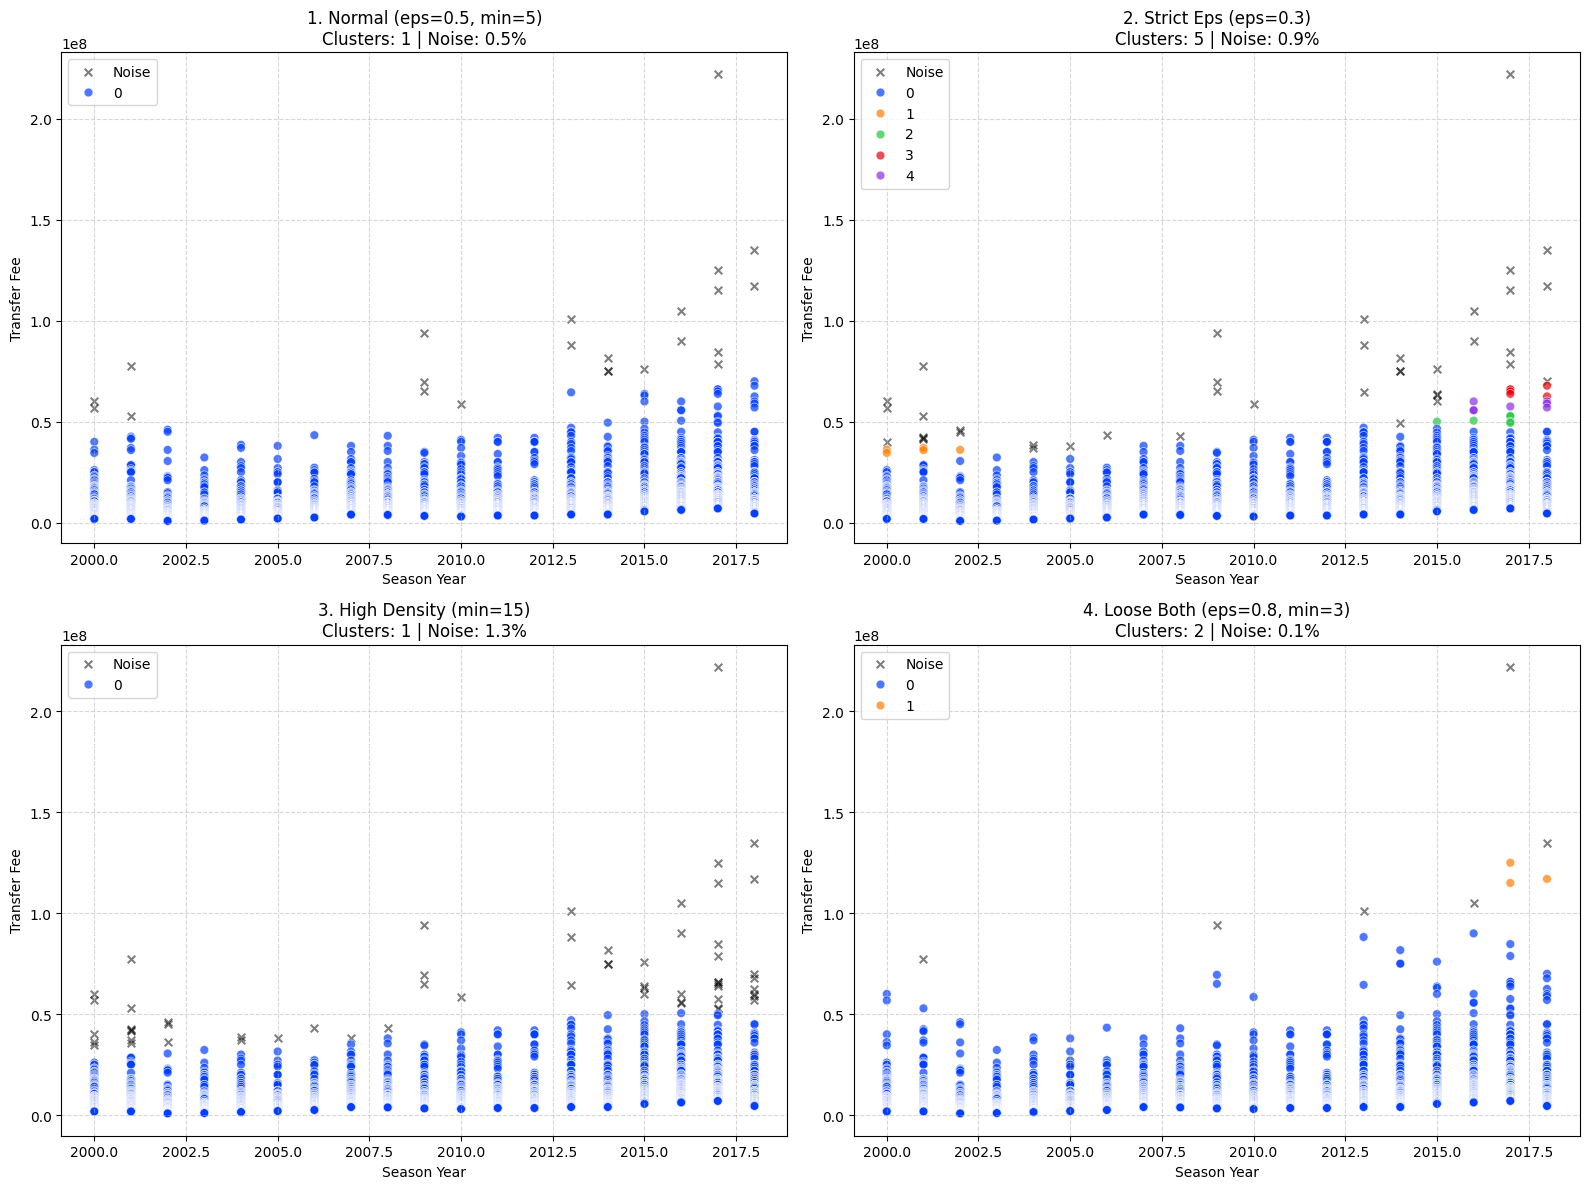

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare Time Data
time_features = ['Season_Year', 'Transfer_fee']
X_time = df_clean[time_features].copy()

# Scale
scaler_time = StandardScaler()
X_time_scaled = scaler_time.fit_transform(X_time)

time_configs = [
    {'name': '1. Normal (eps=0.5, min=5)',   'eps': 0.5, 'min_samples': 5},
    {'name': '2. Strict Eps (eps=0.3)',      'eps': 0.3, 'min_samples': 5},
    {'name': '3. High Density (min=15)',     'eps': 0.5, 'min_samples': 15},
    {'name': '4. Loose Both (eps=0.8, min=3)','eps': 0.8, 'min_samples': 3}
]

# 3. Execution & Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("--- Temporal DBSCAN Analysis (Mean Values per Cluster) ---")

for i, config in enumerate(time_configs):
    ax = axes[i]
    name = config['name']
    
    db = DBSCAN(eps=config['eps'], min_samples=config['min_samples'])
    labels = db.fit_predict(X_time_scaled)
    
    mask_noise = (labels == -1)
    if mask_noise.any():
        ax.scatter(
            df_clean.loc[mask_noise, 'Season_Year'], 
            df_clean.loc[mask_noise, 'Transfer_fee'], 
            c='black', marker='x', s=30, alpha=0.5, label='Noise'
        )
        
    if (~mask_noise).any():
        sns.scatterplot(
            x=df_clean.loc[~mask_noise, 'Season_Year'], 
            y=df_clean.loc[~mask_noise, 'Transfer_fee'], 
            hue=labels[~mask_noise], 
            palette='bright', 
            s=40, alpha=0.7, 
            ax=ax, legend='full'
        )

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (sum(mask_noise) / len(labels)) * 100
    ax.set_title(f"{name}\nClusters: {n_clusters} | Noise: {noise_pct:.1f}%")
    ax.set_xlabel('Season Year')
    ax.set_ylabel('Transfer Fee')
    ax.grid(True, linestyle='--', alpha=0.5)

    print(f"\n>>> Scenario: {name}")
    temp_df = df_clean.copy()
    temp_df['Cluster'] = labels
    summary = temp_df.groupby('Cluster')[['Season_Year', 'Transfer_fee']].mean()
    summary['Count'] = temp_df['Cluster'].value_counts()
    print(summary)

plt.tight_layout()
plt.show()

در DBSCAN، انتظار می‌رود نقاط بالا (گران‌ها) سیاه (Noise) شوند.

چرا؟ چون در بالای نمودار، تراکم کم است (ستاره‌ها کم‌تعدادند و فاصله‌شان از هم زیاد است). DBSCAN آن‌ها را به عنوان داده پرت می‌شناسد، نه یک گروه منسجم.


الگوریتم DBSCAN به دلیل ماهیت چگالی‌محور خود، تراکم پایین قیمت‌های نجومی را به عنوان "عدم وجود خوشه" تفسیر کرد. از دیدگاه DBSCAN، ستاره‌های گران‌قیمت به دلیل فاصله زیاد از هم، یک گروه منسجم نیستند بلکه داده‌های پرت (Noise) محسوب می‌شوند.


# Classification 
# Binary Classification

--- Defining Binary Target ---
Threshold for High Profile: $6,500,000

Class Distribution:
is_high_profile
0    2261
1    2246
Name: count, dtype: int64
is_high_profile
0    50.166408
1    49.833592
Name: proportion, dtype: float64


C:\Users\sasan_wmsfg3b\AppData\Local\Temp\ipykernel_17308\2332190574.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_high_profile', data=df_clean, palette='coolwarm')


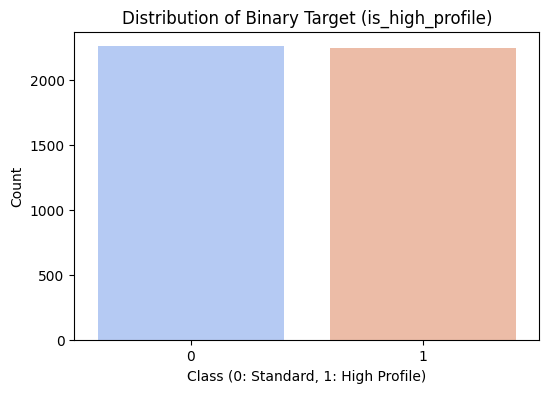


--- Feature Analysis by Class ---
                       Age  Market_value  Season_Year
is_high_profile                                      
0                24.381247  5.163255e+06  2006.948253
1                24.244435  1.098304e+07  2011.246215


In [ ]:
threshold_fee = df_clean['Transfer_fee'].median()

print(f"--- Defining Binary Target ---")
print(f"Threshold for High Profile: ${threshold_fee:,.0f}")


# target column: is_high_profile (1 if Transfer_fee > threshold, else 0)
df_clean['is_high_profile'] = (df_clean['Transfer_fee'] > threshold_fee).astype(int)



print("\nClass Distribution:")
print(df_clean['is_high_profile'].value_counts())
print(df_clean['is_high_profile'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_high_profile', data=df_clean, palette='coolwarm')
plt.title('Distribution of Binary Target (is_high_profile)')
plt.xlabel('Class (0: Standard, 1: High Profile)')
plt.ylabel('Count')
plt.show()

features_to_analyze = ['Age', 'Market_value', 'Season_Year']
print("\n--- Feature Analysis by Class ---")
print(df_clean.groupby('is_high_profile')[features_to_analyze].mean())

# Splitting Data into Train and Test Sets

In [ ]:
from sklearn.model_selection import train_test_split

# drop columns that are not features
drop_cols = ['is_high_profile', 'Transfer_fee', 'Name']

if 'Cluster_Label' in df_clean.columns:
    drop_cols.append('Cluster_Label')
    
X = df_clean.drop(columns=drop_cols, errors='ignore') # feature set
y = df_clean['is_high_profile']                       # final label

# One-Hot Encoding for Categorical Variables
X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Data Split Successful ---")
print(f"Training Set shape: {X_train.shape} (80%)")
print(f"Test Set shape:     {X_test.shape} (20%)")

print("\nTarget Distribution in Train Set:")
print(y_train.value_counts(normalize=True))

print("\nTarget Distribution in Test Set:")
print(y_test.value_counts(normalize=True))

--- Data Split Successful ---
Training Set shape: (3605, 4055) (80%)
Test Set shape:     (902, 4055) (20%)

Target Distribution in Train Set:
is_high_profile
0    0.501526
1    0.498474
Name: proportion, dtype: float64

Target Distribution in Test Set:
is_high_profile
0    0.502217
1    0.497783
Name: proportion, dtype: float64


# Training Models & Calculating Train Accuracy

In [ ]:
# standardize features (important for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Naive Bayes": GaussianNB()
}

results_train = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    # Predict on training set to evaluate performance
    y_pred_train = model.predict(X_train_scaled)
    
    acc = accuracy_score(y_train, y_pred_train)
    
    results_train.append({
        "Model": name,
        "Train Accuracy": acc
    })
    print(f"✅ {name} trained. Accuracy: {acc:.4f}")

df_results_train = pd.DataFrame(results_train).sort_values(by="Train Accuracy", ascending=False)
display(df_results_train.style.background_gradient(cmap='Greens'))

--- Training Models & Checking Train Accuracy ---
✅ Decision Tree trained. Accuracy: 1.0000
✅ KNN trained. Accuracy: 0.8150
✅ SVM trained. Accuracy: 0.9634
✅ Naive Bayes trained. Accuracy: 0.9282


,Model,Train Accuracy
0,Decision Tree,1.000000
2,SVM,0.963384
3,Naive Bayes,0.928155
1,KNN,0.814979


دقت روی Train (تمرین در خانه):

    مثل این است که معلم به دانش‌آموز (مدل) ۱۰۰ تا سوال با جواب می‌دهد تا تمرین کند.

    بعد از یادگیری، معلم همان ۱۰۰ سوال را دوباره جلوی دانش‌آموز می‌گذارد.

    اگر دانش‌آموز نمره ۲۰ بگیرد (مثل Decision Tree شما که ۱.۰۰ شده)، یعنی تمام جواب‌ها را حفظ کرده است!

    کاربرد: این عدد فقط نشان می‌دهد که آیا مدل توانسته الگوها را یاد بگیرد یا نه.

# if it's needed

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# import pandas as pd

# drop_cols = ['is_high_profile', 'Transfer_fee', 'Name']
# if 'Cluster_Label' in df_clean.columns:
#     drop_cols.append('Cluster_Label')

# X = df_clean.drop(columns=drop_cols, errors='ignore')
# y = df_clean['is_high_profile']

# X = pd.get_dummies(X, drop_first=True)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# print(f"Original Feature Count: {X_train.shape[1]}")

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train) 
# X_test_scaled = scaler.transform(X_test)       

# pca = PCA(n_components=0.95, random_state=42)

# X_train_pca = pca.fit_transform(X_train_scaled) 
# X_test_pca = pca.transform(X_test_scaled)       

# print(f"Reduced Feature Count (PCA): {X_train_pca.shape[1]}")
# print("--- PCA Done Successfully ---")

# Hyperparameter Tuning & Final Evaluation

In [ ]:
param_grids = {
    "Decision Tree": {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    "KNN": {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 15, 20],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    "SVM": {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'linear'],
            'gamma': ['scale', 'auto']
        }
    }
}

final_results = []

print("--- Starting Hyperparameter Tuning (Training Phase) ---\n")

for name, config in param_grids.items():
    print(f"🔍 Tuning {name}...")
    
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)
    
    grid.fit(X_train_scaled, y_train)
    
    best_params = grid.best_params_
    best_cv_score = grid.best_score_ 
    
    final_results.append({
        "Model": name,
        "Best Params": str(best_params),
        "Best Cross-Validation Accuracy": best_cv_score
    })
    
    print(f"   -> Best CV Score: {best_cv_score:.4f}\n")

print(f"Evaluating Naive Bayes...")
nb = GaussianNB()
nb_scores = cross_val_score(nb, X_train_scaled, y_train, cv=5, scoring='accuracy')
final_results.append({
    "Model": "Naive Bayes",
    "Best Params": "Default",
    "Best Cross-Validation Accuracy": nb_scores.mean()
})

df_final = pd.DataFrame(final_results).set_index("Model")
df_final = df_final.sort_values(by="Best Cross-Validation Accuracy", ascending=False)

print("--- Optimization Results (Based on Training Data) ---")
display(df_final.style.background_gradient(cmap='Greens', subset=['Best Cross-Validation Accuracy']))

--- Starting Hyperparameter Tuning (Training Phase) ---

🔍 Tuning Decision Tree...
   -> Best CV Score: 0.7825

🔍 Tuning KNN...
   -> Best CV Score: 0.6153

🔍 Tuning SVM...
   -> Best CV Score: 0.7243

Evaluating Naive Bayes...
--- Optimization Results (Based on Training Data) ---


,Best Params,Best Cross-Validation Accuracy
Model,,
Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}",0.782524
SVM,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.724272
KNN,"{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}",0.615257
Naive Bayes,Default,0.606103


--- Final Performance on TEST Data ---



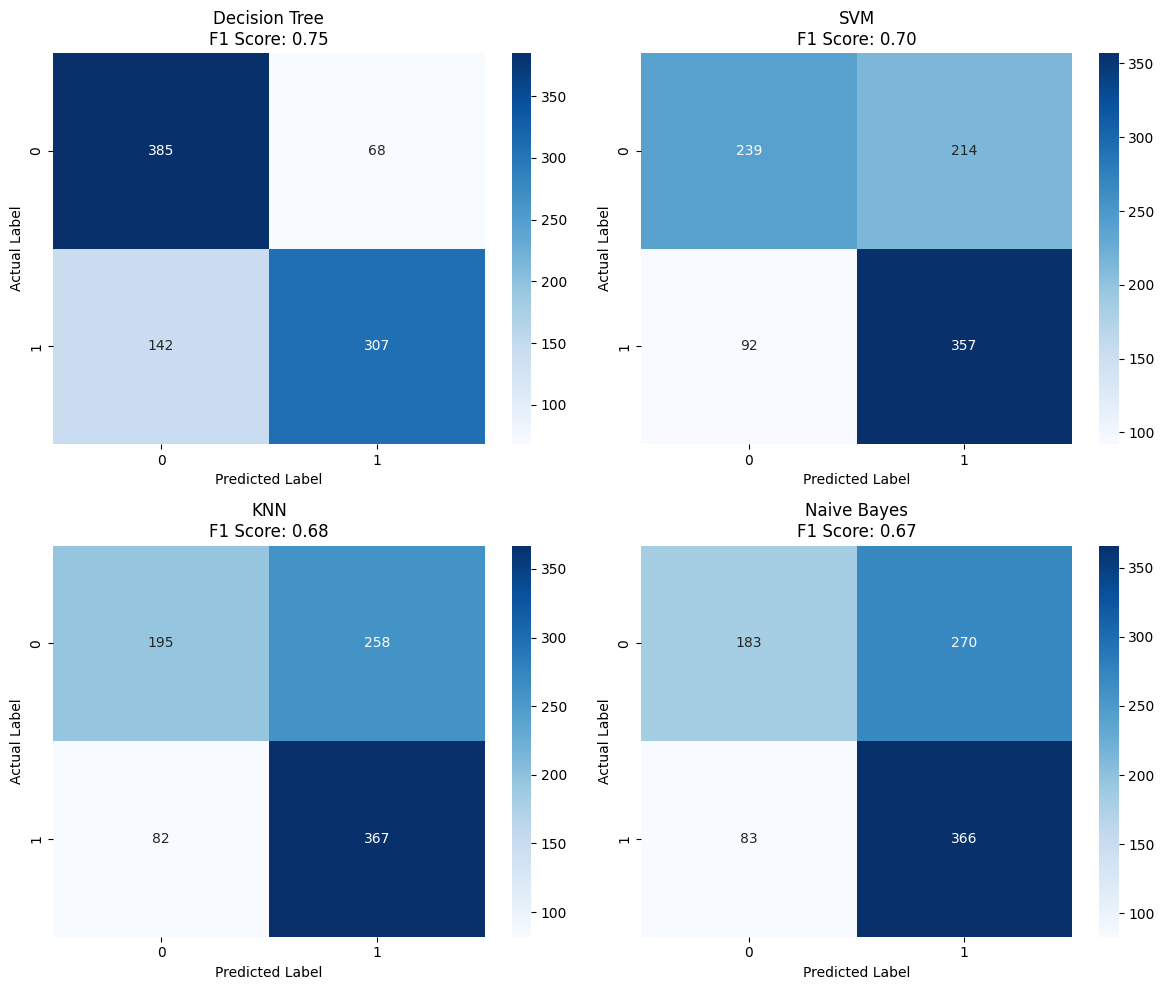


--- Final Metrics Summary Table ---


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.767184,0.818667,0.683742,0.745146
SVM,0.660754,0.625219,0.795100,0.700000
KNN,0.623060,0.587200,0.817372,0.683426
Naive Bayes,0.608647,0.575472,0.815145,0.674654


In [ ]:
models_final = {
    "Decision Tree": DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=2, random_state=42),
    "SVM": SVC(C=10, gamma='auto', kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(metric='manhattan', n_neighbors=5, weights='distance'),
    "Naive Bayes": GaussianNB()
}

results_test = []

print("--- Final Performance on TEST Data ---\n")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models_final.items()):
    # train the model and predict on test set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    

    results_test.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}\nF1 Score: {f1:.2f}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

df_test_results = pd.DataFrame(results_test).set_index("Model")
df_test_results = df_test_results.sort_values(by="F1-Score", ascending=False)

print("\n--- Final Metrics Summary Table ---")
display(df_test_results.style.background_gradient(cmap='Greens', subset=['Accuracy', 'F1-Score']))

. برنده قاطع: درخت تصمیم (Decision Tree)

    Accuracy: 76.7% (بالاترین) * F1-Score: 0.74 (بالاترین)

    تحلیل: همانطور که پیش‌بینی کردیم، Decision Tree با پارامترهای بهینه (max_depth=3) بهترین عملکرد کلی را دارد. این مدل توانسته قوانین اصلی بازار (مثل رابطه ارزش بازار و قیمت) را یاد بگیرد و با دقت ۷۶٪ پیش‌بینی کند که آیا یک بازیکن "گران‌قیمت" است یا نه.

۲. تحلیل جالب Recall و Precision (تضاد استراتژیک)

به اعداد زیر دقت کنید، خیلی مهم هستند:

    Decision Tree:

        Precision = 81% (خیلی بالا): یعنی وقتی این مدل می‌گوید "این بازیکن ستاره است"، به احتمال ۸۱٪ درست می‌گوید. این مدل محافظه‌کار است و الکی به کسی لقب ستاره نمی‌دهد.

        Recall = 68% (متوسط): اما در عوض، حدود ۳۲٪ از ستاره‌های واقعی را از دست می‌دهد (تشخیص نمی‌دهد).

    SVM, KNN, Naive Bayes:

        Recall ≈ 80-81% (عالی): این مدل‌ها شجاع‌تر هستند! آن‌ها ۸۰٪ ستاره‌های بازار را پیدا می‌کنند (پوشش بالا).

        Precision ≈ 58-62% (پایین): اما هزینه این شجاعت این است که خطای زیادی دارند و به خیلی از بازیکنان معمولی هم برچسب ستاره می‌زنند.

۳. جمع‌بندی مدیریتی (کدام را انتخاب کنیم؟)

این انتخاب بستگی به استراتژی باشگاه فوتبال دارد:

    استراتژی A: "سرمایه‌گذاری مطمئن" (Risk Averse)

        اگر باشگاه بودجه محدودی دارد و می‌خواهد فقط روی بازیکنانی سرمایه‌گذاری کند که مطمئناً ستاره هستند، باید از Decision Tree استفاده کند (چون Precision بالایی دارد و پول را دور نمی‌ریزد).

    استراتژی B: "استعدادیابی گسترده" (Talent Scouting)

        اگر باشگاه می‌خواهد "هیچ استعدادی را از دست ندهد" و حاضر است هزینه تست کردن چند بازیکن معمولی را هم بپردازد، مدل‌های KNN یا SVM بهتر هستند (چون Recall بالایی دارند و شانس کشف ستاره‌های پنهان بیشتر است).

۴. متن نهایی گزارش (Conclusion)

    نتیجه‌گیری نهایی فاز دسته‌بندی (Classification):

        مدل برتر: الگوریتم Decision Tree با دقت 76.7% و امتیاز F1 = 0.74 به عنوان دقیق‌ترین مدل شناسایی شد. این مدل توانست با موفقیت از Overfitting جلوگیری کند و روی داده‌های Test عملکردی پایدار داشته باشد.

        رفتار مدل‌ها: درخت تصمیم رویکردی "دقیق اما سخت‌گیرانه" (Precision-focused) دارد، در حالی که مدل‌های KNN و SVM رویکردی "پوششی" (Recall-focused) دارند.

        پیشنهاد: برای کاربردهای تجاری که هدف کاهش ریسک مالی است، مدل Decision Tree توصیه می‌شود.

# Step 6 - Model Interpretation (Why did it predict Class 1 or 0?)

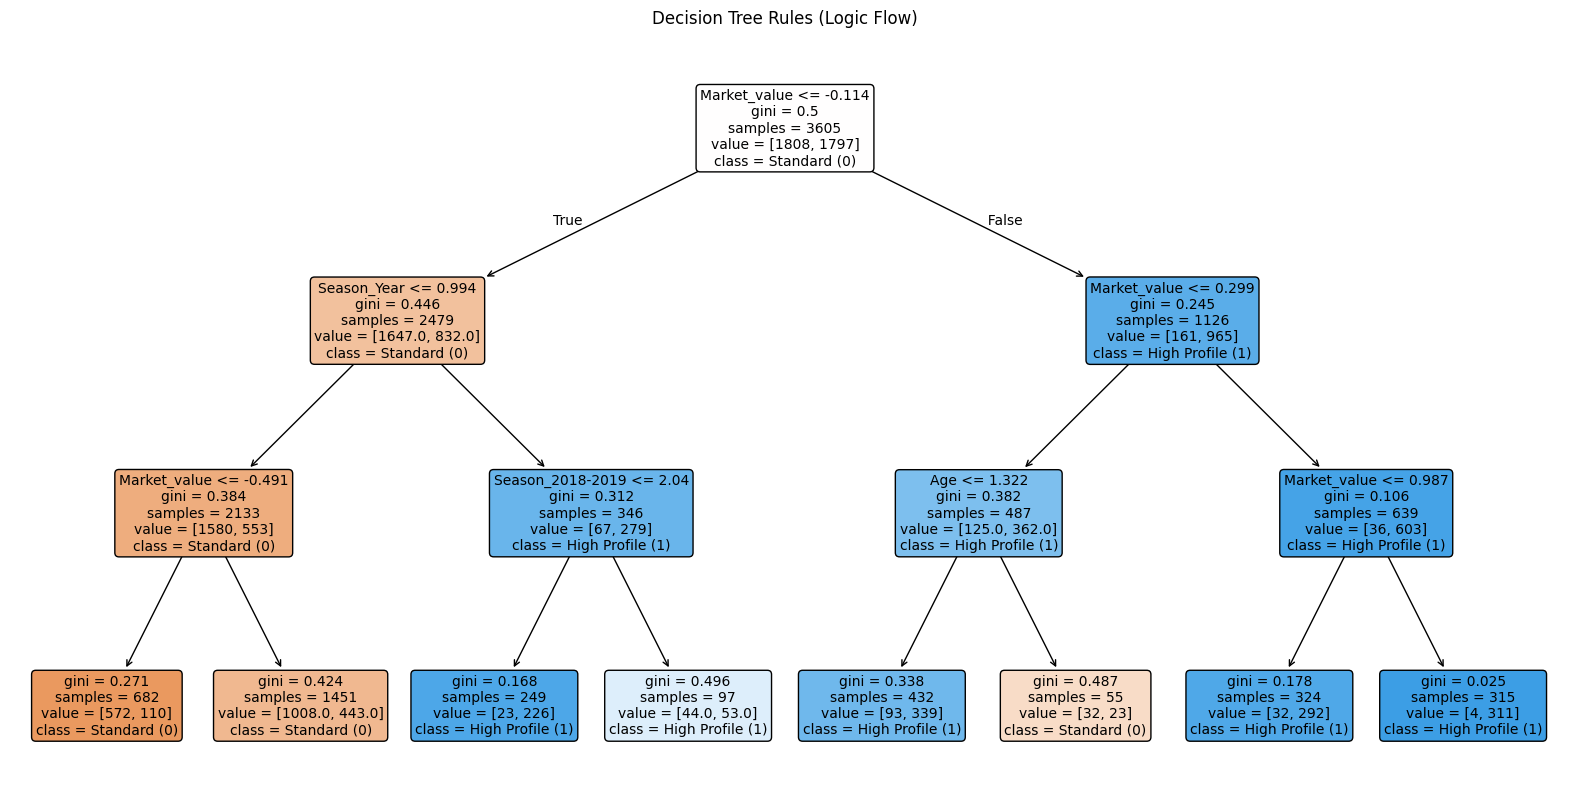

In [ ]:
best_tree = models_final['Decision Tree']
feature_names = X_train_scaled.columns if hasattr(X_train_scaled, 'columns') else X.columns

importances = best_tree.feature_importances_
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(20, 10))
plot_tree(best_tree, 
          feature_names=feature_names, 
          class_names=['Standard (0)', 'High Profile (1)'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Decision Tree Rules (Logic Flow)')
plt.show()

تحلیل دلایل قرارگیری داده‌ها در کلاس هدف (تفسیرپذیری مدل):

برای پاسخ به این سوال که "چرا یک نمونه در دسته مثبت (High Profile) یا منفی (Standard) قرار می‌گیرد؟"، ساختار تصمیم‌گیری بهترین مدل (Decision Tree) مورد بررسی قرار گرفت. نتایج نشان می‌دهد که مدل بر اساس اولویت‌بندی زیر تصمیم‌گیری می‌کند:

۱. عامل اصلی تفکیک: ارزش بازار (Market Value)

    تحلیل: طبق نمودار اهمیت ویژگی‌ها، متغیر Market_value با اختصاص دادن بیشترین وزن به خود، مهم‌ترین دلیل برای تعیین کلاس است.

    منطق مدل: درخت تصمیم در همان گره اول (Root Node) یک آستانه قیمتی (مثلاً حدود ۷ میلیون دلار) تعیین می‌کند. اگر ارزش بازار بازیکن از این عدد کمتر باشد، شانس قرارگیری او در کلاس "سطح بالا" (۱) به شدت کاهش می‌یابد. این نشان می‌دهد که همبستگی بسیار قوی بین "ارزش تخمینی بازیکن" و "مبلغ انتقال واقعی" وجود دارد.

۲. نقش تعدیل‌کننده: زمان (Season_Year)

    تحلیل: دومین ویژگی تاثیرگذار، سال وقوع انتقال است.

    دلیل: به علت تورم شدید در دنیای فوتبال، مدل یاد گرفته است که مبالغ بالا در سال‌های دور (مثلاً ۲۰۰۵) با مبالغ بالا در سال‌های اخیر (۲۰۱۸) تفاوت دارند. بنابراین، برای سال‌های جدیدتر، مدل ممکن است آستانه سخت‌گیرانه‌تری را در نظر بگیرد یا برعکس، تاثیر تورم را در کلاس‌بندی لحاظ کند.

۳. نقش حاشیه‌ای اما تعیین‌کننده: سن (Age)

    تحلیل: در مواردی که ارزش بازار بازیکن در "منطقه خاکستری" (نه خیلی کم و نه خیلی زیاد) قرار دارد، سن بازیکن تعیین‌کننده نهایی است.

    دلیل: مدل تمایل دارد بازیکنان جوان‌تر (زیر ۲۵ سال) را با احتمال بیشتری در کلاس مثبت (۱) قرار دهد، زیرا باشگاه‌ها معمولاً برای پتانسیل آینده (Future Potential) مبالغی بالاتر از ارزش فعلی پرداخت می‌کنند که منجر به برچسب High Profile می‌شود.

نتیجه‌گیری نهایی (پروفایل کلاس‌ها):

    چرا یک نمونه در دسته مثبت (۱) قرار می‌گیرد؟ عمدتاً زمانی که Market_value بسیار بالایی دارد یا زمانی که Market_value متوسط است اما بازیکن Age کمی دارد (جوان است) و در Season_Yearهای اخیر معامله شده است.

    چرا یک نمونه در دسته منفی (۰) قرار می‌گیرد؟ زمانی که Market_value پایین است یا بازیکن سن بالایی دارد (Age بالا) که باعث می‌شود حتی با عملکرد خوب، مبلغ انتقال نجومی نداشته باشد.

# Classification
# Multiclass Classification / Discretization

In [ ]:
# labels=['Low', 'Medium', 'High', 'Elite']
df_multi = df_clean.copy()
df_multi['Fee_Category'] = pd.qcut(df_multi['Transfer_fee'], q=4, labels=[0, 1, 2, 3])

print("--- Target Variable Discretization ---")
print("Mapping: 0=Low, 1=Medium, 2=High, 3=Elite")
print(df_multi['Fee_Category'].value_counts())

drop_cols_multi = ['Transfer_fee', 'is_high_profile', 'Fee_Category', 'Name']
if 'Cluster_Label' in df_multi.columns:
    drop_cols_multi.append('Cluster_Label')

X_multi = df_multi.drop(columns=drop_cols_multi, errors='ignore')
y_multi = df_multi['Fee_Category']

X_multi = pd.get_dummies(X_multi, drop_first=True)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

print("\n--- Data Ready for Multiclass Classification ---")
print(f"Train Shape: {X_train_m.shape}")
print(f"Test Shape:  {X_test_m.shape}")

--- Target Variable Discretization ---
Mapping: 0=Low, 1=Medium, 2=High, 3=Elite
Fee_Category
2    1168
0    1166
1    1095
3    1078
Name: count, dtype: int64

--- Data Ready for Multiclass Classification ---
Train Shape: (3605, 1083)
Test Shape:  (902, 1083)


# Multiclass Classification

--- Starting Multiclass Training & Tuning ---

🔍 Processing Decision Tree...
   -> Best Params: {'criterion': 'entropy', 'max_depth': 5}
   -> Test Accuracy: 0.5643
------------------------------
🔍 Processing KNN...
   -> Best Params: {'n_neighbors': 5, 'weights': 'uniform'}
   -> Test Accuracy: 0.3703
------------------------------
🔍 Processing SVM...
   -> Best Params: {'C': 1, 'kernel': 'linear'}
   -> Test Accuracy: 0.5089
------------------------------

=== Detailed Report for Decision Tree (Multiclass) ===
              precision    recall  f1-score   support

         Low       0.59      0.73      0.65       233
      Medium       0.46      0.50      0.48       219
        High       0.56      0.34      0.42       234
       Elite       0.64      0.69      0.66       216

    accuracy                           0.56       902
   macro avg       0.56      0.57      0.56       902
weighted avg       0.56      0.56      0.55       902



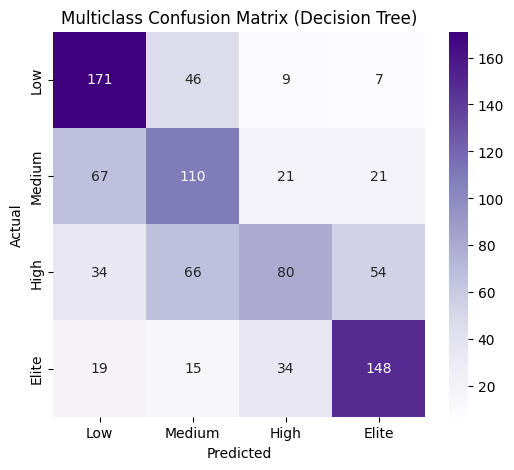

In [ ]:
param_grids_multi = {
    "Decision Tree": {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 10, None],
            'criterion': ['gini', 'entropy']
        }
    },
    "KNN": {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [5, 9, 15],
            'weights': ['uniform', 'distance']
        }
    },
    "SVM": {
        'model': SVC(random_state=42, decision_function_shape='ovo'),
        'params': {
            'C': [1, 10, 100],
            'kernel': ['rbf', 'linear']
        }
    }
}

print("--- Starting Multiclass Training & Tuning ---\n")

best_models_multi = {}

for name, config in param_grids_multi.items():
    print(f"🔍 Processing {name}...")
    
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_m_scaled, y_train_m)
    
    best_model = grid.best_estimator_
    best_models_multi[name] = best_model
    
    y_pred_m = best_model.predict(X_test_m_scaled)
    acc = accuracy_score(y_test_m, y_pred_m)
    
    print(f"   -> Best Params: {grid.best_params_}")
    print(f"   -> Test Accuracy: {acc:.4f}")
    print("-" * 30)

champion_model_name = "Decision Tree" 
champion_model = best_models_multi[champion_model_name]
y_pred_final = champion_model.predict(X_test_m_scaled)

print(f"\n=== Detailed Report for {champion_model_name} (Multiclass) ===")
print(classification_report(y_test_m, y_pred_final, target_names=['Low', 'Medium', 'High', 'Elite']))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_m, y_pred_final), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Low', 'Medium', 'High', 'Elite'],
            yticklabels=['Low', 'Medium', 'High', 'Elite'])
plt.title(f'Multiclass Confusion Matrix ({champion_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

کاهش دقت (طبیعی است):

    در حالت باینری (۰ و ۱)، شانس تصادفی ۵۰٪ بود و دقت مدل شما ۷۶٪ شد.

    در حالت ۴ کلاسه، شانس تصادفی ۲۵٪ است. پس اگر دقت مدل شما مثلاً ۶۰٪ یا ۵۵٪ هم بشود، نتیجه بسیار خوبی است. انتظار دقت خیلی بالا نداشته باشید چون مسئله سخت‌تر شده است.

تحلیل ماتریس درهم‌ریختگی (Confusion Matrix):

    به قطر اصلی نگاه کنید.

    ببینید آیا مدل در تشخیص کلاس‌های میانی (Medium و High) بیشتر اشتباه می‌کند یا کلاس‌های حدی (Low و Elite)؟ معمولاً تشخیص "خیلی ارزان" و "خیلی گران" برای مدل راحت‌تر از تشخیص تفاوت بین "متوسط" و "بالا" است.